In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")


In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Exploratory Data Analysis

In [4]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()

Shape: (150, 5)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


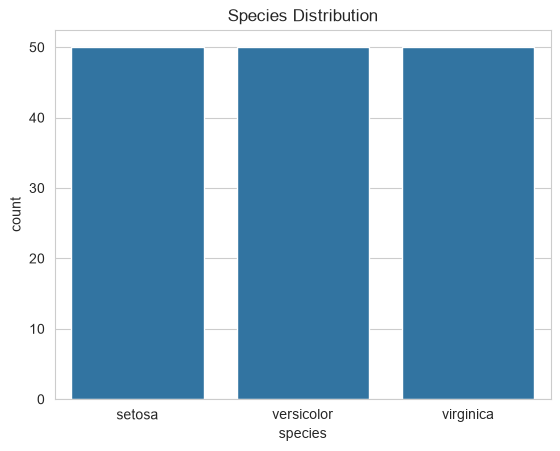

In [5]:
print(df['species'].value_counts())
sns.countplot(x='species', data=df)
plt.title("Species Distribution")
plt.show()

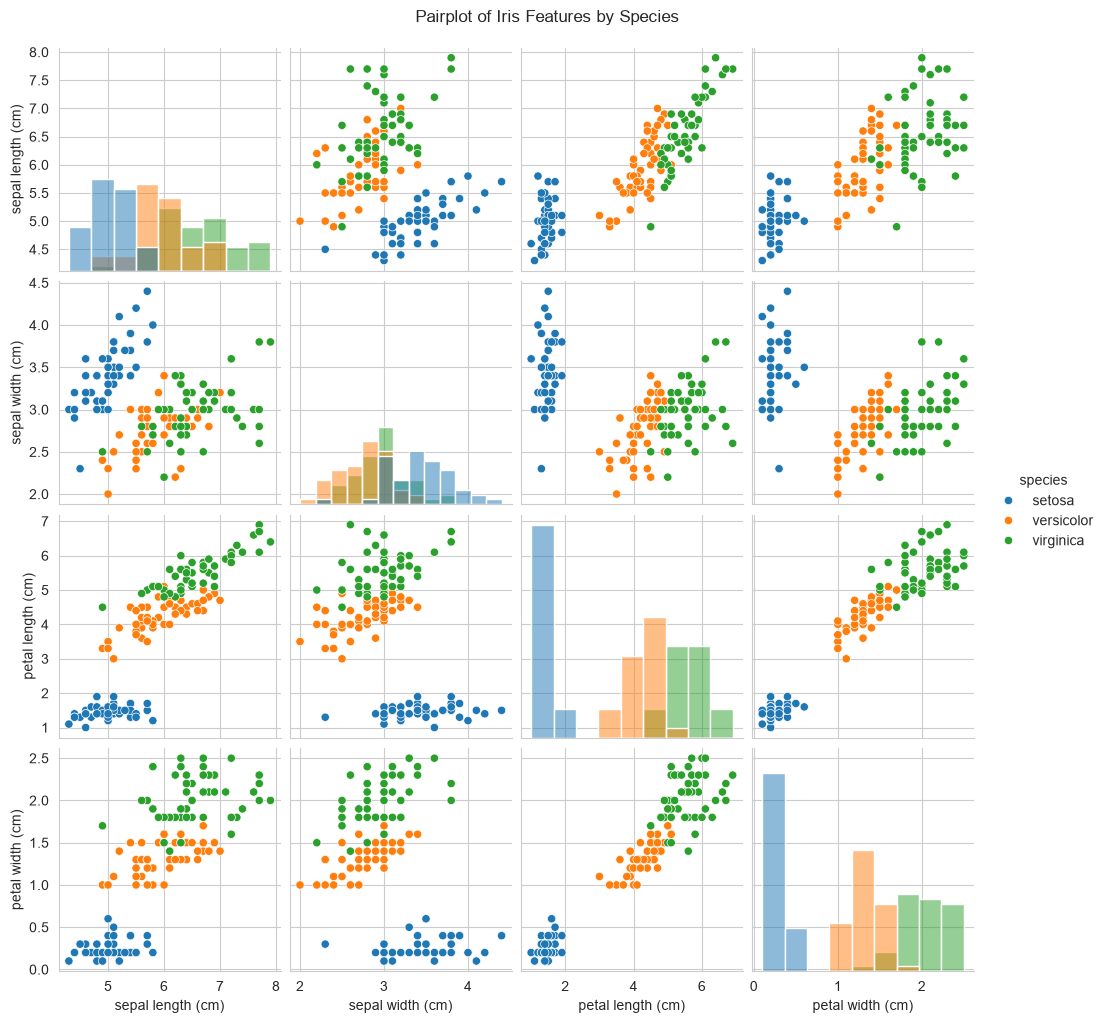

In [6]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

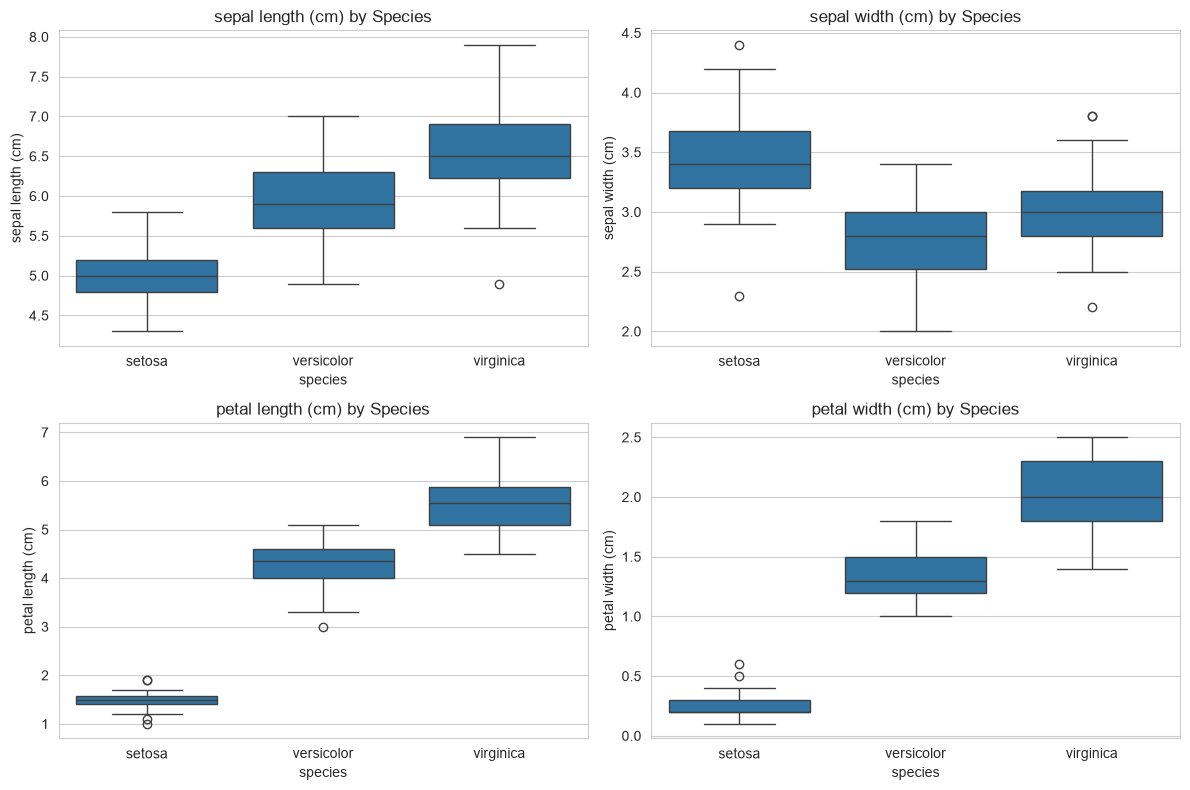

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(x='species', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()

## Feature Selection Discussion

Petal length and petal width show the clearest separation between species —
Setosa is almost perfectly separable using just these two features, while
sepal measurements overlap more between Versicolor and Virginica. This is
visible clearly in the pairplot and boxplots above. So petal-based features
are the most discriminative for this classification task.

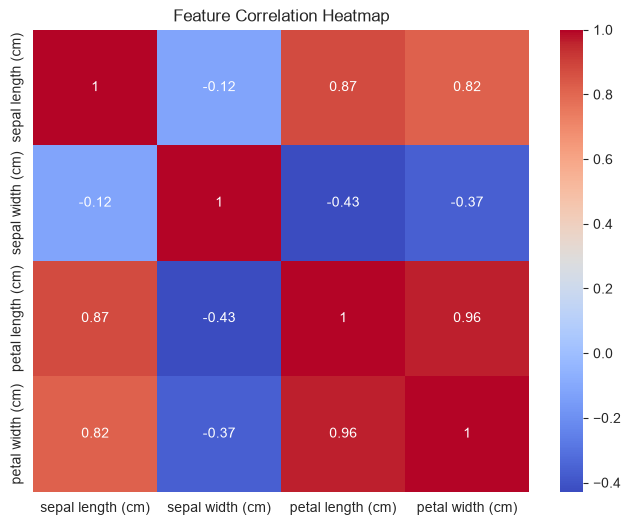

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (120, 4) Test size: (30, 4)


## Model Training
Training 3 classifiers: Logistic Regression, K-Nearest Neighbors, and Decision Tree.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
K-Nearest Neighbors trained.
Decision Tree trained.


In [11]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Model: K-Nearest Neighbors
Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00

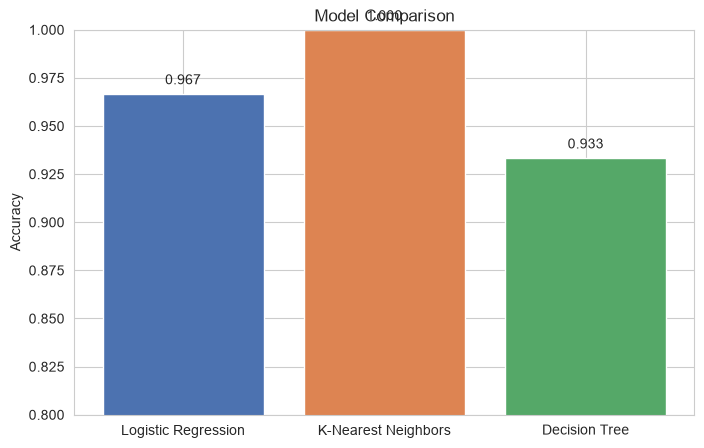

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.8, 1.0)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha='center')
plt.show()

Best performing model: K-Nearest Neighbors with accuracy 1.0000


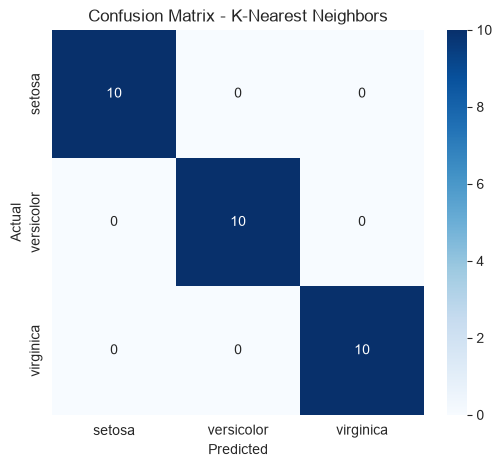

In [13]:
best_model_name = max(results, key=results.get)
print(f"Best performing model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

y_pred_best = trained_models[best_model_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

Based on the evaluation, K-Nearest Neighbors achieved the highest accuracy (100%) 
on the test set. The Iris dataset is nearly linearly separable, especially for 
Setosa, which is why simple models like Logistic Regression also perform very well.
Petal length and width were the most important features for classification.